# Tarang ECG Classifier v3 — Final
**Changes in this version:**
- Window: 187 samples (93 pre + 94 post R-peak) — matches EFR32MG26 firmware exactly
- Datasets: MIT-BIH Arrhythmia + MIT-BIH Supraventricular Arrhythmia Database (SVDB)
- Dual-input model: ECG waveform (depthwise separable CNN) + RR rhythm features (Dense branch)
- Block 4 restored at 64ch for S-class discrimination
- Focal alpha S boosted to 0.60, AUG_COPIES S=15 — addresses S F1 underperformance
- V recall floor raised back to 0.92 (was 0.85 during diagnosis run)
- `SparseFocalLoss.get_config()` added — `load_model` works without custom_objects
- All load sites use `load_weights` — no custom loss deserialization
- `json.dump` float32 serialization fix applied

```

In [1]:
import os
import json
import subprocess
import warnings
from collections import Counter

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import regularizers

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)
warnings.filterwarnings('ignore')

# ── PATHS — edit these ────────────────────────────────────────────────────────
MITBIH_PATH = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-arrhythmia-database-1.0.0'
SVDB_PATH   = 'C:\MMD Public\Hackathons\Team Ocelleon\dataset\mit-bih-supraventricular-arrhythmia-database-1.0.0'

OUTPUTS_DIR      = 'outputs'
MODEL_CHECKPOINT = f'{OUTPUTS_DIR}/tarang_best.keras'
TFLITE_PATH      = f'{OUTPUTS_DIR}/tarang_int8.tflite'
HEADER_PATH      = f'{OUTPUTS_DIR}/tarang_model.h'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ── WINDOW — DO NOT CHANGE without updating firmware ─────────────────────────
WINDOW_PRE  = 93
WINDOW_POST = 94
WINDOW_LEN  = WINDOW_PRE + WINDOW_POST   # 187 samples = ~519ms at 360Hz

FS = 360   # MIT-BIH and SVDB are both 360Hz

CONFIDENCE_THRESHOLD = 0.70

print("TensorFlow:", tf.__version__)
print("WFDB      :", wfdb.__version__)
print(f"Window    : {WINDOW_LEN} samples ({WINDOW_LEN/FS*1000:.1f}ms)")
print(f"MIT-BIH   : {MITBIH_PATH}")
print(f"SVDB      : {SVDB_PATH}  (exists={os.path.isdir(SVDB_PATH)})")
print(f"Outputs   : {OUTPUTS_DIR}/")

Memory growth enabled for 1 GPU(s)
TensorFlow: 2.10.1
WFDB      : 4.1.2
Window    : 187 samples (519.4ms)
MIT-BIH   : C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-arrhythmia-database-1.0.0
SVDB      : C:\MMD Public\Hackathons\Team Ocelleon\dataset\mit-bih-supraventricular-arrhythmia-database-1.0.0  (exists=True)
Outputs   : outputs/


In [2]:
# AAMI/ANSI EC57 — clinical standard, do not modify
BEAT_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V', 'F': 'V',   # Fusion → V (conservative/pacemaker safety)
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}
CLASSES_TO_USE = ['N', 'V', 'S']

MITBIH_ALL_RECORDS = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]

# Patient-wise test/val split — NEVER seen during training
MITBIH_TEST_RECORDS = [
    101,106,108,109,112,114,115,116,118,119,
    201,202,203,205,207,208,209,210,217,219,
    221,223,228,231,233,234
]
MITBIH_VAL_RECORDS   = [105, 124, 214, 220]
MITBIH_TRAIN_RECORDS = [r for r in MITBIH_ALL_RECORDS
                        if r not in MITBIH_TEST_RECORDS
                        and r not in MITBIH_VAL_RECORDS]

# SVDB: 78 records (e800–e877) — train only, no test leak
# Read actual records dynamically from the downloaded dataset
try:
    with open(f'{SVDB_PATH}/RECORDS', 'r') as f:
        SVDB_RECORDS = [line.strip() for line in f if line.strip()]
except FileNotFoundError:
    SVDB_RECORDS = []

print(f"MIT-BIH train : {len(MITBIH_TRAIN_RECORDS)} records")
print(f"MIT-BIH val   : {len(MITBIH_VAL_RECORDS)} records")
print(f"MIT-BIH test  : {len(MITBIH_TEST_RECORDS)} records (held out)")
print(f"SVDB train    : {len(SVDB_RECORDS)} records (S-class boost)")

MIT-BIH train : 18 records
MIT-BIH val   : 4 records
MIT-BIH test  : 26 records (held out)
SVDB train    : 78 records (S-class boost)


=== RECORD 100 ===
Signals : ['MLII', 'V5']
Fs      : 360 Hz
Length  : 650000 samples (30.1 min)
Beats   : 2274


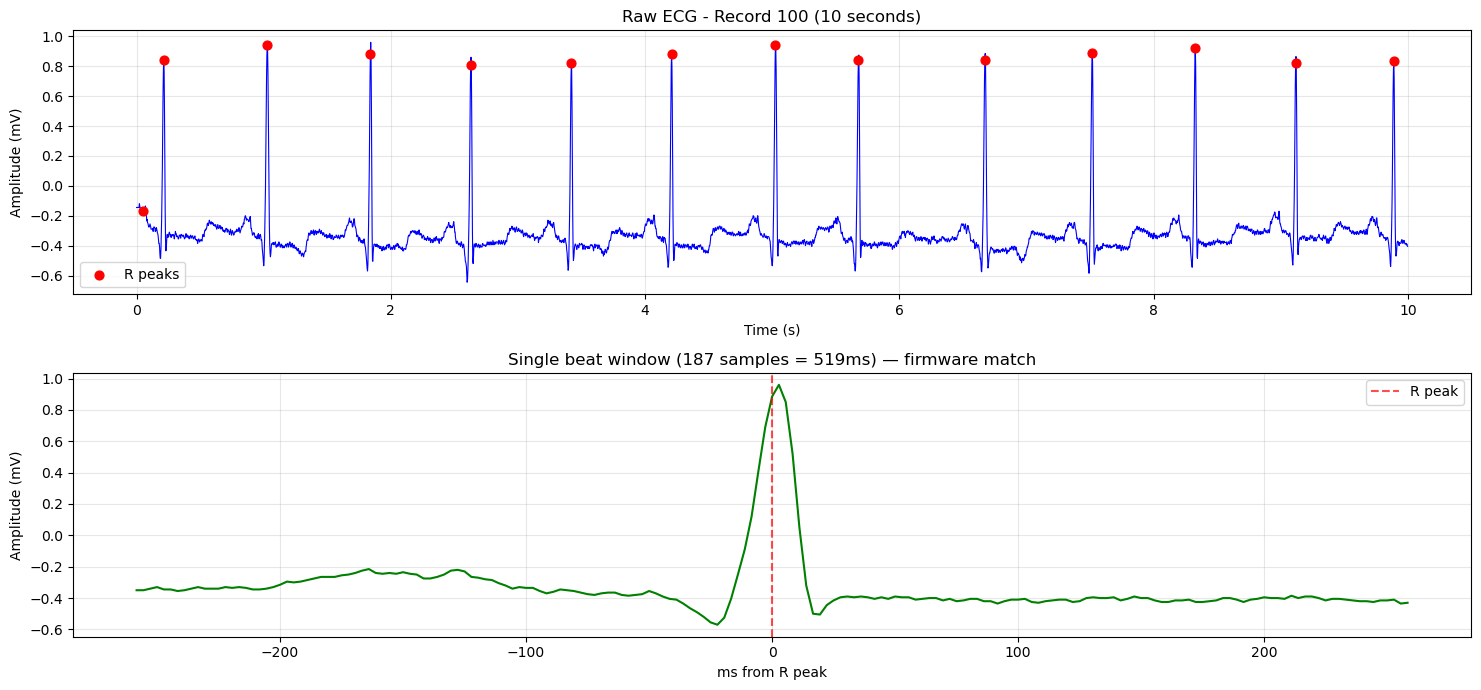

In [3]:
record     = wfdb.rdrecord(f'{MITBIH_PATH}/100')
annotation = wfdb.rdann(f'{MITBIH_PATH}/100', 'atr')

print("=== RECORD 100 ===")
print(f"Signals : {record.sig_name}")
print(f"Fs      : {record.fs} Hz")
print(f"Length  : {record.sig_len} samples ({record.sig_len/record.fs/60:.1f} min)")
print(f"Beats   : {len(annotation.sample)}")

signal = record.p_signal[:, 0]
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

t = np.arange(0, 10*FS) / FS
axes[0].plot(t, signal[:10*FS], 'b-', linewidth=0.8)
r_in_win = [p for p in annotation.sample if p < 10*FS]
axes[0].scatter([p/FS for p in r_in_win], [signal[p] for p in r_in_win],
                color='red', s=40, zorder=5, label='R peaks')
axes[0].set_title('Raw ECG - Record 100 (10 seconds)')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude (mV)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

center = r_in_win[3]
t2 = np.arange(-WINDOW_PRE, WINDOW_POST) / FS * 1000
axes[1].plot(t2, signal[center-WINDOW_PRE:center+WINDOW_POST], 'g-', linewidth=1.5)
axes[1].axvline(0, color='red', alpha=0.7, linestyle='--', label='R peak')
axes[1].set_title(f'Single beat window ({WINDOW_LEN} samples = {WINDOW_LEN/FS*1000:.0f}ms) — firmware match')
axes[1].set_xlabel('ms from R peak'); axes[1].set_ylabel('Amplitude (mV)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/ecg_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
def rolling_window_normalize(signal, window_samples=10800):
    """
    Simulates firmware 30s Welford rolling normalization.
    Fast pandas version — milliseconds per record.
    window_samples = 10800 = 30s × 360Hz
    """
    s    = pd.Series(signal.astype(np.float64))
    roll = s.rolling(window=window_samples, min_periods=1)
    mean = roll.mean()
    std  = roll.std(ddof=0).fillna(0).clip(lower=1e-8)
    return ((s - mean) / std).values.astype(np.float32)


def compute_rr_features(peaks, beat_idx):
    """
    5 RR-interval features for one beat.
    peaks     : full sorted R-peak sample array for the record
    beat_idx  : index of current beat in peaks[]
    Returns float32 (5,): [rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5] in seconds.
    Firmware replicates this from the Pan-Tompkins RR buffer.
    """
    n = len(peaks)
    i = beat_idx
    prev_idx = max(0, i-1)
    next_idx = min(n-1, i+1)
    rr_prev  = (peaks[i] - peaks[prev_idx]) / FS
    rr_next  = (peaks[next_idx] - peaks[i]) / FS
    rr_ratio = rr_prev / max(rr_next, 1e-4)

    lo = max(0, i-2); hi = min(n-1, i+2)
    local_rrs = np.diff(peaks[lo:hi+1]).astype(np.float32) / FS
    if len(local_rrs) == 0:
        rr_mean_5, rr_std_5 = rr_prev, 0.0
    else:
        rr_mean_5 = float(np.mean(local_rrs))
        rr_std_5  = float(np.std(local_rrs))

    return np.array([rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5], dtype=np.float32)

print("rolling_window_normalize() and compute_rr_features() defined.")

rolling_window_normalize() and compute_rr_features() defined.


In [5]:
def load_records(db_path, record_list, source_tag, two_channel=True):
    """
    Load beats from a list of records.
    Returns: beats (N,187,2), rr (N,5), labels (N,), record_ids (N,)
    Single normalisation pass — no double norm, no uint16 round-trip.
    """
    all_beats, all_rr, all_labels, all_recs = [], [], [], []

    for rec_id in record_list:
        rec_str = str(rec_id)
        try:
            record     = wfdb.rdrecord(f'{db_path}/{rec_str}')
            annotation = wfdb.rdann(f'{db_path}/{rec_str}', 'atr')

            # Single normalisation — windowed, no NLMS conversion for MIT-BIH/SVDB
            ecg_ch0 = rolling_window_normalize(record.p_signal[:, 0])
            if two_channel and record.p_signal.shape[1] > 1:
                ecg_ch1 = rolling_window_normalize(record.p_signal[:, 1])
            else:
                ecg_ch1 = ecg_ch0   # SVDB single-lead: duplicate channel

            all_peaks  = annotation.sample
            all_syms   = annotation.symbol
            valid_idxs = [i for i, s in enumerate(all_syms)
                          if BEAT_MAP.get(s, None) in CLASSES_TO_USE]

            beats_this = 0
            for idx in valid_idxs:
                peak   = all_peaks[idx]
                mapped = BEAT_MAP[all_syms[idx]]

                if peak - WINDOW_PRE < 0 or peak + WINDOW_POST >= len(ecg_ch0):
                    continue

                beat = np.stack([
                    ecg_ch0[peak - WINDOW_PRE : peak + WINDOW_POST],
                    ecg_ch1[peak - WINDOW_PRE : peak + WINDOW_POST],
                ], axis=-1).astype(np.float32)   # (187, 2)

                if np.any(np.isnan(beat)) or np.any(np.isinf(beat)):
                    continue

                rr = compute_rr_features(all_peaks, idx)

                all_beats.append(beat)
                all_rr.append(rr)
                all_labels.append(mapped)
                all_recs.append(f'{source_tag}_{rec_str}')
                beats_this += 1

            print(f"  {source_tag}/{rec_str}: {beats_this} beats")

        except Exception as ex:
            print(f"  {source_tag}/{rec_str}: FAILED — {ex}")

    return (
        np.array(all_beats,  dtype=np.float32),
        np.array(all_rr,     dtype=np.float32),
        np.array(all_labels, dtype=object),
        np.array(all_recs,   dtype=object),
    )

print("load_records() defined.")

load_records() defined.


In [6]:
print("Loading MIT-BIH Arrhythmia database...")
mb_beats, mb_rr, mb_labels, mb_recs = load_records(
    MITBIH_PATH, MITBIH_ALL_RECORDS, 'mitbih', two_channel=True
)
print(f"\nMIT-BIH: {mb_beats.shape}  classes={Counter(mb_labels)}")

Loading MIT-BIH Arrhythmia database...
  mitbih/100: 2271 beats
  mitbih/101: 1862 beats
  mitbih/102: 103 beats
  mitbih/103: 2084 beats
  mitbih/104: 165 beats
  mitbih/105: 2567 beats
  mitbih/106: 2027 beats
  mitbih/107: 59 beats
  mitbih/108: 1762 beats
  mitbih/109: 2531 beats
  mitbih/111: 2124 beats
  mitbih/112: 2539 beats
  mitbih/113: 1794 beats
  mitbih/114: 1879 beats
  mitbih/115: 1952 beats
  mitbih/116: 2411 beats
  mitbih/117: 1534 beats
  mitbih/118: 2277 beats
  mitbih/119: 1987 beats
  mitbih/121: 1863 beats
  mitbih/122: 2476 beats
  mitbih/123: 1517 beats
  mitbih/124: 1619 beats
  mitbih/200: 2600 beats
  mitbih/201: 1963 beats
  mitbih/202: 2136 beats
  mitbih/203: 2976 beats
  mitbih/205: 2656 beats
  mitbih/207: 1859 beats
  mitbih/208: 2951 beats
  mitbih/209: 3005 beats
  mitbih/210: 2648 beats
  mitbih/212: 2747 beats
  mitbih/213: 3250 beats
  mitbih/214: 2259 beats
  mitbih/215: 3363 beats
  mitbih/217: 406 beats
  mitbih/219: 2154 beats
  mitbih/220: 20

In [7]:
print("Loading SVDB (Supraventricular Arrhythmia Database)...")
svdb_ok = os.path.isdir(SVDB_PATH)

if svdb_ok:
    sv_beats, sv_rr, sv_labels, sv_recs = load_records(
        SVDB_PATH, SVDB_RECORDS, 'svdb', two_channel=False
    )
    print(f"\nSVDB: {sv_beats.shape}  classes={Counter(sv_labels)}")
else:
    print(f"SVDB not found at {SVDB_PATH}")
    print("Run: wfdb.dl_database('svdb', dl_dir=SVDB_PATH)  then re-run this cell.")
    print("Continuing with MIT-BIH only.")
    sv_beats  = np.empty((0, WINDOW_LEN, 2), dtype=np.float32)
    sv_rr     = np.empty((0, 5),             dtype=np.float32)
    sv_labels = np.array([], dtype=object)
    sv_recs   = np.array([], dtype=object)

Loading SVDB (Supraventricular Arrhythmia Database)...
  svdb/800: 1883 beats
  svdb/801: 2507 beats
  svdb/802: 1670 beats
  svdb/803: 2068 beats
  svdb/804: 2832 beats
  svdb/805: 2296 beats
  svdb/806: 3020 beats
  svdb/807: 1940 beats
  svdb/808: 1774 beats
  svdb/809: 2542 beats
  svdb/810: 1902 beats
  svdb/811: 1434 beats
  svdb/812: 1842 beats
  svdb/820: 2349 beats
  svdb/821: 3130 beats
  svdb/822: 2332 beats
  svdb/823: 2859 beats
  svdb/824: 2417 beats
  svdb/825: 2794 beats
  svdb/826: 2660 beats
  svdb/827: 1860 beats
  svdb/828: 1912 beats
  svdb/829: 1966 beats
  svdb/840: 2384 beats
  svdb/841: 1851 beats
  svdb/842: 2557 beats
  svdb/843: 2705 beats
  svdb/844: 1708 beats
  svdb/845: 2883 beats
  svdb/846: 1679 beats
  svdb/847: 1760 beats
  svdb/848: 4255 beats
  svdb/849: 2138 beats
  svdb/850: 1836 beats
  svdb/851: 2626 beats
  svdb/852: 2662 beats
  svdb/853: 2217 beats
  svdb/854: 2727 beats
  svdb/855: 2535 beats
  svdb/856: 2850 beats
  svdb/857: 2581 beats
  

Label encoding: {0: 'N', 1: 'S', 2: 'V'}

X_all   : (285789, 187, 2)  (beats, 187, 2ch)
X_rr_all: (285789, 5)  (beats, 5 RR features)

Train: 218,830  Counter({'N': 193334, 'S': 13889, 'V': 11607})
Val  : 8,492   Counter({'N': 8017, 'V': 350, 'S': 125})
Test : 58,467  Counter({'N': 51466, 'V': 6040, 'S': 961})


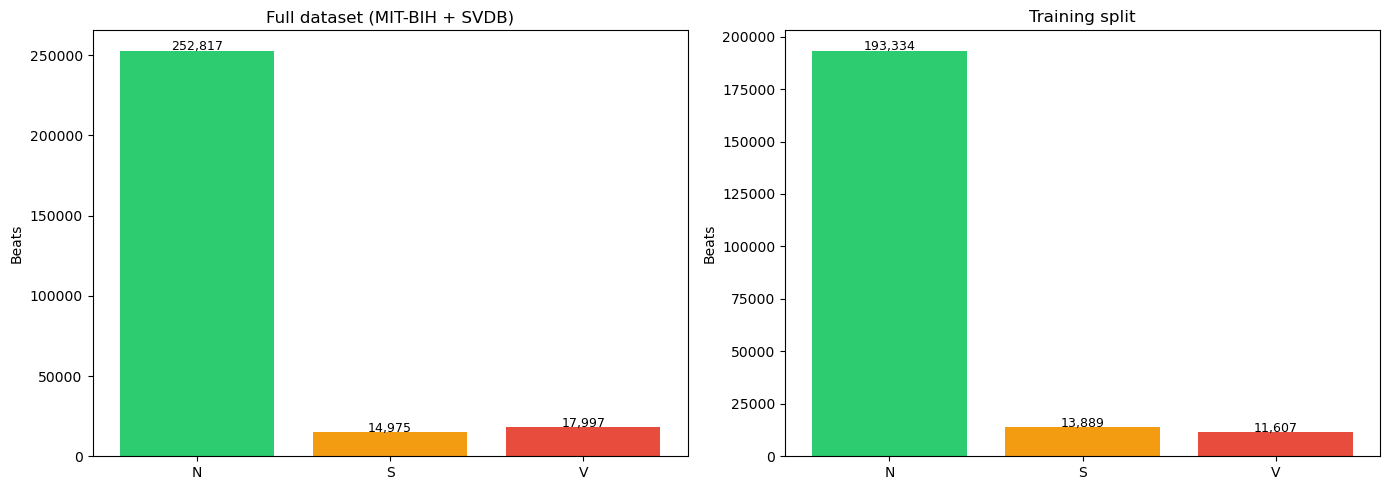

In [8]:
X_all      = np.concatenate([mb_beats, sv_beats], axis=0)
X_rr_all   = np.concatenate([mb_rr,    sv_rr],   axis=0)
y_raw_all  = np.concatenate([mb_labels, sv_labels])
recs_all   = np.concatenate([mb_recs,   sv_recs])

le    = LabelEncoder()
y_all = le.fit_transform(y_raw_all)
print("Label encoding:", {i: c for i, c in enumerate(le.classes_)})

test_mask  = np.array([
    r.startswith('mitbih_') and int(r.split('_')[1]) in MITBIH_TEST_RECORDS
    for r in recs_all])
val_mask   = np.array([
    r.startswith('mitbih_') and int(r.split('_')[1]) in MITBIH_VAL_RECORDS
    for r in recs_all])
train_mask = ~test_mask & ~val_mask   # MIT-BIH train + all SVDB

X_train,    X_val,    X_test    = X_all[train_mask],    X_all[val_mask],    X_all[test_mask]
X_rr_train, X_rr_val, X_rr_test = X_rr_all[train_mask], X_rr_all[val_mask], X_rr_all[test_mask]
y_train,    y_val,    y_test    = y_all[train_mask],    y_all[val_mask],    y_all[test_mask]

print(f"\nX_all   : {X_all.shape}  (beats, {WINDOW_LEN}, 2ch)")
print(f"X_rr_all: {X_rr_all.shape}  (beats, 5 RR features)")
print(f"\nTrain: {len(X_train):,}  {Counter(le.inverse_transform(y_train))}")
print(f"Val  : {len(X_val):,}   {Counter(le.inverse_transform(y_val))}")
print(f"Test : {len(X_test):,}  {Counter(le.inverse_transform(y_test))}")

# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71','#f39c12','#e74c3c']
cls_names = list(le.classes_)
for ax, ctr, title in zip(
        axes,
        [Counter(y_raw_all), Counter(le.inverse_transform(y_train))],
        ['Full dataset (MIT-BIH + SVDB)', 'Training split']):
    counts = [ctr.get(c, 0) for c in cls_names]
    ax.bar(cls_names, counts, color=colors)
    ax.set_title(title); ax.set_ylabel('Beats')
    for i, v in enumerate(counts):
        ax.text(i, v+100, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/class_distribution.png', dpi=100)
plt.show()

In [9]:
def augment_batch(X_c, X_rr_c, class_name, n_copies):
    """
    Augment ECG (N,187,2) and RR features (N,5) consistently.
    Returns aug_ecg (N*n_copies,187,2), aug_rr (N*n_copies,5).
    """
    n = len(X_c)
    ecg_list, rr_list = [], []
    t_arr = np.linspace(0, 2*np.pi, WINDOW_LEN)

    for _ in range(n_copies):
        a = X_c.copy()

        # Amplitude ±15%
        a *= np.random.uniform(0.85, 1.15, (n, 1, 1))

        # Baseline wander
        freqs  = np.random.uniform(0.3, 0.8, n)
        amps   = np.random.uniform(0.0, 0.12, n)
        wander = (amps[:, None] * np.sin(freqs[:, None] * t_arr[None, :]))[:, :, None]
        a += wander

        # Gaussian noise
        a += np.random.normal(0, np.random.uniform(0.01, 0.04), a.shape).astype(np.float32)

        # Time shift ±10 samples (tighter window = less shift vs v2's ±20)
        shifts = np.random.randint(-10, 11, n)
        for i in range(n):
            a[i] = np.roll(a[i], shifts[i], axis=0)

        # S: P-wave perturbation
        if class_name == 'S':
            a[:, :40, :] *= np.random.uniform(0.4, 1.6, (n, 1, 1))

        ecg_list.append(a.astype(np.float32))

        # RR feature augmentation
        rr = X_rr_c.copy()
        if class_name == 'S':
            rr[:, 0] *= np.random.uniform(0.6, 0.95, n)          # rr_prev shorter (premature)
            rr[:, 2]  = rr[:, 0] / np.maximum(rr[:, 1], 1e-4)   # recompute ratio
            rr[:, 4] *= np.random.uniform(1.1, 1.5, n)           # higher local variability
        elif class_name == 'V':
            rr[:, 1] *= np.random.uniform(1.05, 1.2, n)          # compensatory pause
            rr[:, 4] *= np.random.uniform(1.0, 1.3, n)

        rr *= np.random.uniform(0.95, 1.05, rr.shape)
        rr  = np.clip(rr, 0.0, 3.0).astype(np.float32)
        rr_list.append(rr)

    return np.concatenate(ecg_list, axis=0), np.concatenate(rr_list, axis=0)


# S=15 copies (was 10) — S F1 was 0.16, needs maximum augmentation
# V=6 copies (was 5)
# N=0 — majority, no augmentation
AUG_COPIES = {'N': 0, 'V': 6, 'S': 15}

print("Augmenting minority classes...")
ecg_aug_list = [X_train]
rr_aug_list  = [X_rr_train]
y_aug_list   = [y_train]

for ci, cname in enumerate(le.classes_):
    n_copies = AUG_COPIES.get(cname, 0)
    if n_copies == 0:
        continue
    mask = y_train == ci
    aug_ecg, aug_rr = augment_batch(X_train[mask], X_rr_train[mask], cname, n_copies)
    ecg_aug_list.append(aug_ecg)
    rr_aug_list.append(aug_rr)
    y_aug_list.append(np.tile(y_train[mask], n_copies))

X_train_aug    = np.concatenate(ecg_aug_list, axis=0)
X_rr_train_aug = np.concatenate(rr_aug_list,  axis=0)
y_train_aug    = np.concatenate(y_aug_list,   axis=0)

idx = np.random.permutation(len(X_train_aug))
X_train_aug    = X_train_aug[idx]
X_rr_train_aug = X_rr_train_aug[idx]
y_train_aug    = y_train_aug[idx]

print(f"Before: {Counter(le.inverse_transform(y_train))}")
print(f"After : {Counter(le.inverse_transform(y_train_aug))}")
print(f"ECG   : {X_train_aug.shape}")
print(f"RR    : {X_rr_train_aug.shape}")

Augmenting minority classes...
Before: Counter({'N': 193334, 'S': 13889, 'V': 11607})
After : Counter({'S': 222224, 'N': 193334, 'V': 81249})
ECG   : (496807, 187, 2)
RR    : (496807, 5)


In [10]:
def build_tarang_cnn_v3(ecg_shape=(WINDOW_LEN, 2), rr_shape=(5,), num_classes=3):
    """
    Dual-input ECG + RR model.
    ECG branch: depthwise separable Conv1D × 4 blocks + GAP (~26KB params)
    RR branch:  Dense(16) → Dense(8)
    Merged:     Dense(32) → softmax
    Total ~30KB INT8 — well under EFR32 50KB limit.

    Block 4 (64ch, kernel 3) retained for S-class morphology discrimination.
    """
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')

    # Block 1 — local waveform / P-wave
    x = tf.keras.layers.SeparableConv1D(
        16, 7, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(ecg_in)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    # Block 2 — QRS morphology
    x = tf.keras.layers.SeparableConv1D(
        32, 5, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    # Block 3 — T wave / ST segment
    x = tf.keras.layers.SeparableConv1D(
        64, 5, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout1D(0.15)(x)

    # Block 4 — S-class discrimination (restored — needed for subtle morphology)
    x = tf.keras.layers.SeparableConv1D(
        64, 3, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)   # (64,)

    # RR branch
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dense(8,  activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    # Merge
    merged = tf.keras.layers.Concatenate()([x, r])   # (72,)
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)

    out = tf.keras.layers.Dense(num_classes, activation='softmax',
                                name='predictions')(merged)

    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=out, name='Tarang_ECG_v3')


model = build_tarang_cnn_v3(num_classes=len(le.classes_))
model.summary()

p = model.count_params()
print(f"\nParameters: {p:,}")
print(f"Est INT8  : ~{p/1024:.1f} KB  ({'PASS' if p < 51200 else 'OVER 50KB'})")

Model: "Tarang_ECG_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 ecg_input (InputLayer)         [(None, 187, 2)]     0           []                               
                                                                                                  
 separable_conv1d (SeparableCon  (None, 187, 16)     46          ['ecg_input[0][0]']              
 v1D)                                                                                             
                                                                                                  
 batch_normalization (BatchNorm  (None, 187, 16)     64          ['separable_conv1d[0][0]']       
 alization)                                                                                       
                                                                                      

In [11]:
class SparseFocalLoss(tf.keras.losses.Loss):
    """
    Focal loss for class-imbalanced ECG.
    get_config() included — load_model works without custom_objects.
    Use load_weights instead (faster, no serialisation issues).
    """
    def __init__(self, alpha, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self._alpha_list = list(alpha)
        self.alpha = tf.constant(alpha, dtype=tf.float32)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true   = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred   = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_onehot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        ce       = -y_onehot * tf.math.log(y_pred)
        pt       = tf.reduce_sum(y_onehot * y_pred, axis=-1)
        fw       = tf.pow(1.0 - pt, self.gamma)
        aw       = tf.reduce_sum(self.alpha * y_onehot, axis=-1)
        return tf.reduce_mean(aw * fw * tf.reduce_sum(ce, axis=-1))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'alpha': self._alpha_list, 'gamma': self.gamma})
        return cfg

# label order: le.classes_ is alphabetical → N=0, S=1, V=2
# S alpha raised to 0.60 (was 0.50) — S F1 was 0.16, needs harder focus
focal_alpha = [0.10, 0.60, 0.30]
focal_gamma = 2.0
print(f"Focal Loss: alpha={focal_alpha} (N, S, V), gamma={focal_gamma}")
print(f"Classes   : {list(le.classes_)}")

Focal Loss: alpha=[0.1, 0.6, 0.3] (N, S, V), gamma=2.0
Classes   : ['N', 'S', 'V']


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=SparseFocalLoss(alpha=focal_alpha, gamma=focal_gamma),
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=8, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_CHECKPOINT, monitor='val_loss',
        save_best_only=True, verbose=0
    ),
]

history = model.fit(
    [X_train_aug, X_rr_train_aug], y_train_aug,
    validation_data=([X_val, X_rr_val], y_val),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# float32 fix — numpy values aren't JSON serializable directly
with open(f'{OUTPUTS_DIR}/training_history.json', 'w') as f:
    json.dump({k: [float(x) for x in v] for k, v in history.history.items()}, f)
print(f"History saved.")

Epoch 1/150
15526/15526 [==============================] - 337s 21ms/step - loss: 0.0342 - accuracy: 0.8709 - val_loss: 0.0554 - val_accuracy: 0.0248 - lr: 5.0000e-04
Epoch 2/150
15526/15526 [==============================] - 332s 21ms/step - loss: 0.0224 - accuracy: 0.9180 - val_loss: 0.0295 - val_accuracy: 0.8620 - lr: 5.0000e-04
Epoch 3/150
15526/15526 [==============================] - 346s 22ms/step - loss: 0.0201 - accuracy: 0.9267 - val_loss: 0.0367 - val_accuracy: 0.7310 - lr: 5.0000e-04
Epoch 4/150
15526/15526 [==============================] - 338s 22ms/step - loss: 0.0188 - accuracy: 0.9310 - val_loss: 0.0278 - val_accuracy: 0.8940 - lr: 5.0000e-04
Epoch 5/150
15526/15526 [==============================] - 342s 22ms/step - loss: 0.0179 - accuracy: 0.9347 - val_loss: 0.0675 - val_accuracy: 0.0148 - lr: 5.0000e-04
Epoch 6/150
15526/15526 [==============================] - 342s 22ms/step - loss: 0.0172 - accuracy: 0.9368 - val_loss: 0.0424 - val_accuracy: 0.6872 - lr: 5.0000e-0

In [13]:
print('='*60)
print('THRESHOLD TUNING — validation set (V-safety-first)')
print('='*60)

# load_weights: rebuilds architecture, loads weights only
# Avoids SparseFocalLoss deserialization entirely
model = build_tarang_cnn_v3(num_classes=len(le.classes_))
model.load_weights(MODEL_CHECKPOINT)

y_val_probs = model.predict([X_val, X_rr_val], batch_size=128, verbose=0)

n_idx = int(np.where(le.classes_ == 'N')[0])
s_idx = int(np.where(le.classes_ == 'S')[0])
v_idx = int(np.where(le.classes_ == 'V')[0])

V_RECALL_FLOOR  = 0.92   # back to 0.92 — 0.85 caused N:49% recall
best_macro_f1   = 0.0
best_thresholds = {'S': 0.5, 'V': 0.5}
best_v_recall   = 0.0

for t_v in np.arange(0.10, 0.55, 0.02):
    for t_s in np.arange(0.10, 0.60, 0.02):
        y_pred = np.full(len(y_val), n_idx, dtype=int)
        y_pred[y_val_probs[:, s_idx] > t_s] = s_idx
        y_pred[y_val_probs[:, v_idx] > t_v] = v_idx   # V overrides S — safety

        v_recall = (np.sum((y_val==v_idx) & (y_pred==v_idx))
                    / max(np.sum(y_val==v_idx), 1))
        if v_recall < V_RECALL_FLOOR:
            continue

        macro = f1_score(y_val, y_pred, average='macro', zero_division=0)
        if macro > best_macro_f1:
            best_macro_f1   = macro
            best_v_recall   = v_recall
            best_thresholds = {'S': round(t_s, 2), 'V': round(t_v, 2)}

print(f"Best thresholds: S>{best_thresholds['S']}  V>{best_thresholds['V']}")
print(f"Val Macro F1   : {best_macro_f1:.3f}")
print(f"V recall       : {best_v_recall:.3f}  (floor={V_RECALL_FLOOR})")

print('\n' + '='*60)
print('EVALUATION — TEST SET (MIT-BIH patient-wise held out)')
print('='*60)

y_pred_probs = model.predict([X_test, X_rr_test], batch_size=128, verbose=0)
y_pred_test  = np.full(len(y_test), n_idx, dtype=int)
y_pred_test[y_pred_probs[:, s_idx] > best_thresholds['S']] = s_idx
y_pred_test[y_pred_probs[:, v_idx] > best_thresholds['V']] = v_idx

print(classification_report(y_test, y_pred_test, target_names=le.classes_))

macro_f1  = f1_score(y_test, y_pred_test, average='macro')
per_class = f1_score(y_test, y_pred_test, average=None)
print(f"Macro F1: {macro_f1:.3f}")
for cls, f1 in zip(le.classes_, per_class):
    print(f"  F1 {cls}: {f1:.3f}  [{'PASS ✓' if f1>=0.85 else 'NEEDS WORK'}]")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

THRESHOLD TUNING — validation set (V-safety-first)
Best thresholds: S>0.48  V>0.28
Val Macro F1   : 0.614
V recall       : 0.929  (floor=0.92)

EVALUATION — TEST SET (MIT-BIH patient-wise held out)
              precision    recall  f1-score   support

           N       0.98      0.81      0.89     51466
           S       0.08      0.17      0.10       961
           V       0.39      0.89      0.54      6040

    accuracy                           0.81     58467
   macro avg       0.48      0.62      0.51     58467
weighted avg       0.91      0.81      0.84     58467

Macro F1: 0.511
  F1 N: 0.887  [PASS ✓]
  F1 S: 0.104  [NEEDS WORK]
  F1 V: 0.541  [NEEDS WORK]

Confusion Matrix:
[[41629  1826  8011]
 [  298   163   500]
 [  467   183  5390]]


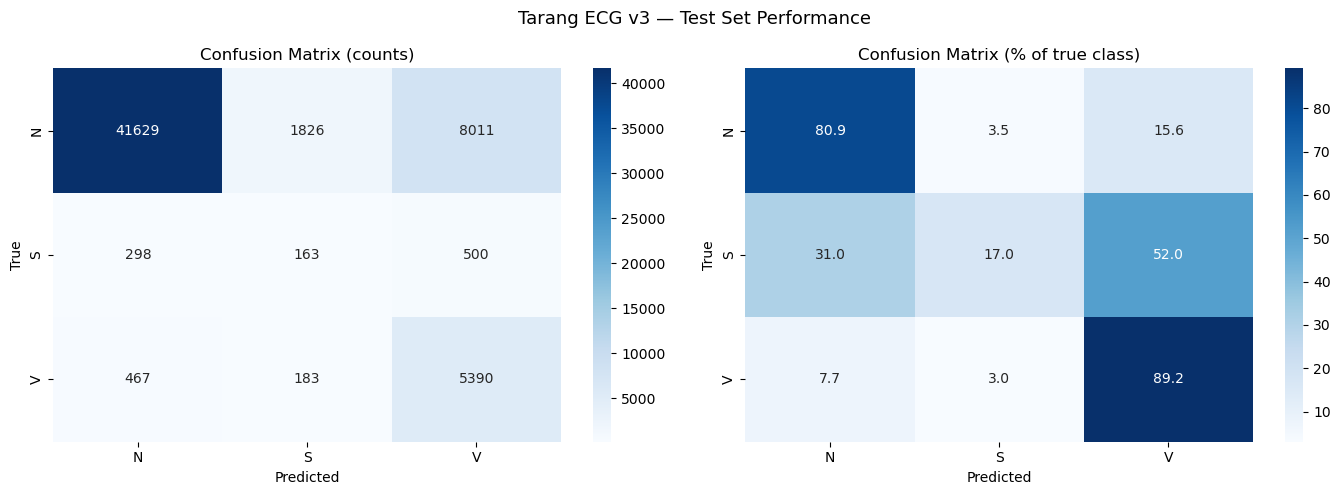

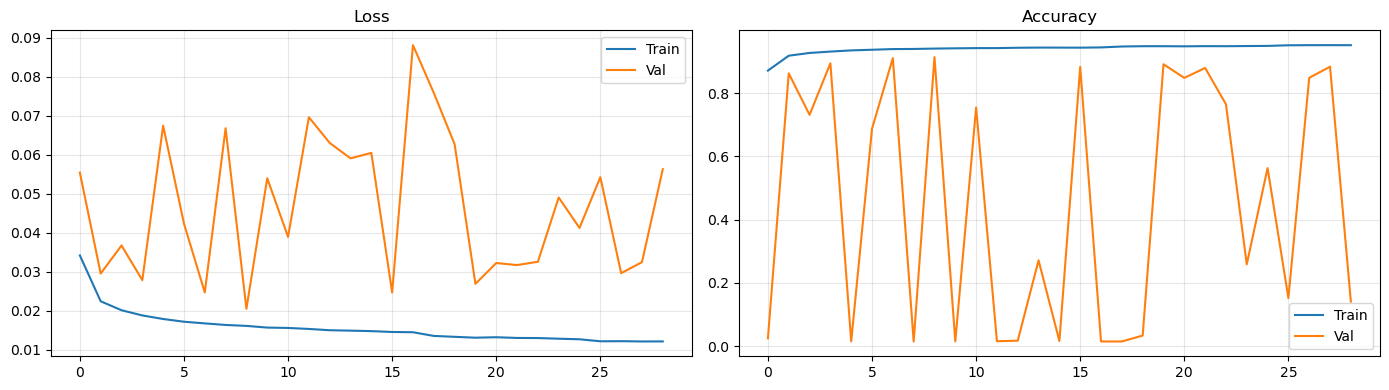

In [14]:
try:
    hist_data = history.history
except NameError:
    with open(f'{OUTPUTS_DIR}/training_history.json') as f:
        hist_data = json.load(f)

cm     = confusion_matrix(y_test, y_pred_test)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, None] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix (% of true class)')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
plt.suptitle('Tarang ECG v3 — Test Set Performance', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist_data['loss'],     label='Train')
axes[0].plot(hist_data['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(hist_data['accuracy'],     label='Train')
axes[1].plot(hist_data['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
def apply_run_filter(predictions, min_run=3, window=10):
    """Suppress isolated anomaly predictions — reduces false BLE wake events."""
    filtered = predictions.copy()
    for i in range(window, len(predictions)):
        if predictions[i] != n_idx and np.sum(predictions[i-window:i] != n_idx) < min_run:
            filtered[i] = n_idx
    return filtered

y_pred_filtered = apply_run_filter(y_pred_test)

print("=== BLE Run Filter ===")
print(f"Before: Macro F1 = {f1_score(y_test, y_pred_test,     average='macro'):.3f}")
print(f"After : Macro F1 = {f1_score(y_test, y_pred_filtered,  average='macro'):.3f}")
for cls, idx_ in [('N',n_idx),('V',v_idx),('S',s_idx)]:
    b = np.sum((y_test==idx_)&(y_pred_test==idx_))    / max(np.sum(y_test==idx_),1)
    a = np.sum((y_test==idx_)&(y_pred_filtered==idx_)) / max(np.sum(y_test==idx_),1)
    print(f"  {cls} recall: {b:.3f} → {a:.3f}")
fa_b = np.sum((y_test==n_idx)&(y_pred_test!=n_idx))
fa_a = np.sum((y_test==n_idx)&(y_pred_filtered!=n_idx))
print(f"False BLE alerts: {fa_b} → {fa_a}  ({(fa_b-fa_a)/max(fa_b,1)*100:.1f}% reduction)")

=== BLE Run Filter ===
Before: Macro F1 = 0.511
After : Macro F1 = 0.482
  N recall: 0.809 → 0.841
  V recall: 0.892 → 0.723
  S recall: 0.170 → 0.073
False BLE alerts: 9837 → 8199  (16.7% reduction)


In [16]:
print("=== Peak Jitter Degradation Test ===")
print("Simulates Pan-Tompkins misalignment on dry-pad ECG\n")

def jitter_macro_f1(mdl, X_ecg, X_rr, y, jitter_std, thresholds):
    if jitter_std == 0:
        Xj = X_ecg
    else:
        j  = np.random.normal(0, jitter_std, len(X_ecg)).astype(int)
        Xj = np.array([np.roll(X_ecg[i], j[i], axis=0) for i in range(len(X_ecg))])
    probs = mdl.predict([Xj, X_rr], batch_size=128, verbose=0)
    preds = np.full(len(y), n_idx, dtype=int)
    preds[probs[:, s_idx] > thresholds['S']] = s_idx
    preds[probs[:, v_idx] > thresholds['V']] = v_idx
    return f1_score(y, preds, average='macro', zero_division=0)

base = jitter_macro_f1(model, X_test, X_rr_test, y_test, 0, best_thresholds)
print(f"{'Jitter':>10}  {'F1':>8}  {'Drop':>8}  Status")
print("-"*48)
for j in [0, 5, 10, 15, 20]:
    f1   = jitter_macro_f1(model, X_test, X_rr_test, y_test, j, best_thresholds)
    drop = base - f1
    print(f"  ±{j:>2} smp   {f1:.3f}   {drop:.3f}   {'OK' if drop<0.05 else 'WIDEN SHIFT'}")

=== Peak Jitter Degradation Test ===
Simulates Pan-Tompkins misalignment on dry-pad ECG

    Jitter        F1      Drop  Status
------------------------------------------------
  ± 0 smp   0.511   0.000   OK
  ± 5 smp   0.506   0.004   OK
  ±10 smp   0.504   0.007   OK
  ±15 smp   0.502   0.009   OK
  ±20 smp   0.498   0.012   OK


In [17]:
# RR normalization stats — computed from CLEAN train data (not augmented)
# Firmware must apply same normalization before INT8 quantization
RR_MEAN = X_rr_train.mean(axis=0)
RR_STD  = X_rr_train.std(axis=0)
RR_STD[RR_STD < 1e-8] = 1e-8

feature_names = ['rr_prev','rr_next','rr_ratio','rr_mean_5','rr_std_5']
print("RR normalization stats:")
for i, name in enumerate(feature_names):
    print(f"  {name}: mean={RR_MEAN[i]:.5f}  std={RR_STD[i]:.5f}")

model = build_tarang_cnn_v3(num_classes=len(le.classes_))
model.load_weights(MODEL_CHECKPOINT)

def representative_dataset():
    idx = np.random.choice(len(X_train), min(1000, len(X_train)), replace=False)
    for i in idx:
        ecg_s = X_train[i:i+1].astype(np.float32)
        rr_s  = ((X_rr_train[i:i+1] - RR_MEAN) / RR_STD).astype(np.float32)
        yield [ecg_s, rr_s]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations              = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset     = representative_dataset
converter.target_spec.supported_ops  = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type       = tf.int8
converter.inference_output_type      = tf.int8

print("\nQuantizing to INT8...")
tflite_model = converter.convert()
print("Done.")

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"\nINT8 size: {size_kb:.1f} KB  ({'PASS ✓' if size_kb<50 else 'FAIL — trim model'})")

interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()
in_details  = interp.get_input_details()
out_details = interp.get_output_details()

# Identify ECG vs RR tensor by shape
ecg_det = next(d for d in in_details if d['shape'][1] == WINDOW_LEN)
rr_det  = next(d for d in in_details if d['shape'][1] == 5)
out_det = out_details[0]

ecg_scale, ecg_zp = ecg_det['quantization']
rr_scale,  rr_zp  = rr_det['quantization']
out_scale, out_zp  = out_det['quantization']

print(f"ECG input  : scale={ecg_scale:.6f}  zp={ecg_zp}  (expect ~0.031)")
print(f"RR input   : scale={rr_scale:.6f}  zp={rr_zp}")
print(f"Output     : scale={out_scale:.6f}  zp={out_zp}")

if ecg_scale > 0.1:
    print("WARNING: ECG scale too high — check representative_dataset normalization")

# INT8 accuracy verification
n        = min(2000, len(X_test))
X_e_samp = X_test[:n]
X_r_samp = ((X_rr_test[:n] - RR_MEAN) / RR_STD).astype(np.float32)
y_samp   = y_test[:n]

float_preds = np.argmax(model.predict([X_e_samp, X_r_samp], batch_size=128, verbose=0), axis=1)
float_acc   = np.mean(float_preds == y_samp) * 100

correct = 0
for i in range(n):
    xeq = np.clip(np.round(X_e_samp[i:i+1]/ecg_scale+ecg_zp),-128,127).astype(np.int8)
    xrq = np.clip(np.round(X_r_samp[i:i+1]/rr_scale +rr_zp), -128,127).astype(np.int8)
    interp.set_tensor(ecg_det['index'], xeq)
    interp.set_tensor(rr_det['index'],  xrq)
    interp.invoke()
    out_f = (interp.get_tensor(out_det['index']).astype(np.float32) - out_zp) * out_scale
    if np.argmax(out_f) == y_samp[i]:
        correct += 1

int8_acc = correct / n * 100
drop     = float_acc - int8_acc
print(f"\nFloat32 acc: {float_acc:.2f}%")
print(f"INT8    acc: {int8_acc:.2f}%")
print(f"Drop       : {drop:.2f}%  ({'PASS ✓' if drop<3 else 'FAIL — check normalization'})")

print(f"\n{'='*55}")
print("COPY THESE DEFINES INTO FIRMWARE")
print('='*55)
print(f"#define ECG_INPUT_SCALE        {ecg_scale:.8f}f")
print(f"#define ECG_INPUT_ZERO_POINT   {ecg_zp}")
print(f"#define RR_INPUT_SCALE         {rr_scale:.8f}f")
print(f"#define RR_INPUT_ZERO_POINT    {rr_zp}")
print(f"#define OUTPUT_SCALE           {out_scale:.8f}f")
print(f"#define OUTPUT_ZERO_POINT      {out_zp}")
print(f"#define CONFIDENCE_THRESH_INT8 {int(round(CONFIDENCE_THRESHOLD/out_scale+out_zp))}")
for i, name in enumerate(feature_names):
    print(f"#define RR_MEAN_{name.upper():<14} {RR_MEAN[i]:.6f}f")
for i, name in enumerate(feature_names):
    print(f"#define RR_STD_{name.upper():<15} {RR_STD[i]:.6f}f")

RR normalization stats:
  rr_prev: mean=0.34932  std=0.22482
  rr_next: mean=0.34965  std=0.22536
  rr_ratio: mean=1.57827  std=55.94291
  rr_mean_5: mean=0.34843  std=0.21460
  rr_std_5: mean=0.03076  std=0.06028

Quantizing to INT8...


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmp7jeefrwq\assets


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmp7jeefrwq\assets


RuntimeError: tensorflow/lite/kernels/depthwise_conv.cc:116 NumDimensions(input) != 4 (3 != 4)Node number 3 (DEPTHWISE_CONV_2D) failed to prepare.

In [ ]:
try:
    result = subprocess.run(['xxd', '-i', TFLITE_PATH], capture_output=True, text=True)
    xxd_ok = result.returncode == 0 and bool(result.stdout)
except FileNotFoundError:
    xxd_ok = False

if xxd_ok:
    with open(HEADER_PATH, 'w') as f:
        f.write('// Tarang ECG CNN v3 — INT8 dual-input (ECG + RR)\n// Auto-generated\n\n')
        f.write('#pragma once\n\n')
        f.write(result.stdout)
    print(f"Generated {HEADER_PATH} (xxd)")
else:
    with open(TFLITE_PATH, 'rb') as f:
        data = f.read()
    hex_lines = ['  ' + ', '.join(f'0x{b:02x}' for b in data[i:i+12]) + ','
                 for i in range(0, len(data), 12)]
    with open(HEADER_PATH, 'w') as f:
        f.write('// Tarang ECG CNN v3 — INT8 dual-input (ECG + RR)\n// Auto-generated\n\n')
        f.write('#pragma once\n\n')
        f.write(f'#define TARANG_MODEL_LEN {len(data)}\n\n')
        f.write('alignas(8) const unsigned char tarang_int8_tflite[] = {\n')
        f.write('\n'.join(hex_lines))
        f.write('\n};\n')
    print(f"Generated {HEADER_PATH} ({len(data):,} bytes, Python fallback — xxd not found)")

## Firmware Integration Notes

### `tarang_ai_process()` — call signature

```c
// tarang_ai.h
typedef struct {
    float rr_prev;    // seconds, from Pan-Tompkins RR buffer
    float rr_next;    // seconds (use 0.0f if next peak not yet arrived — model handles gracefully)
    float rr_ratio;   // rr_prev / rr_next
    float rr_mean_5;  // mean of ±2 local RR intervals (seconds)
    float rr_std_5;   // std  of ±2 local RR intervals (seconds)
} tarang_rr_features_t;

tarang_label_t tarang_ai_process(
    const int8_t  *ecg_window_q,   // 187 samples × 2 channels, INT8-quantized, z-score normalised
    const float   *rr_raw,         // rr_features[5], RAW (not yet normalised)
    tarang_conf_t *conf_out
);
```

### RR normalization before quantization

```c
// Step 1: normalize  →  x_norm = (x_raw - RR_MEAN_xxx) / RR_STD_xxx
// Step 2: quantize   →  x_q = clamp(round(x_norm / RR_INPUT_SCALE + RR_INPUT_ZERO_POINT), -128, 127)
// Constants are printed by the quantization cell above.
```

### Two-input TFLite Micro invocation

```c
// Tensor indices — check tarang_model.h or print interp.get_input_details()
TfLiteTensor *ecg_tensor = interpreter->input(ECG_TENSOR_IDX);
TfLiteTensor *rr_tensor  = interpreter->input(RR_TENSOR_IDX);

// ECG: 187 samples × 2 channels
memcpy(ecg_tensor->data.int8, ecg_window_q, WINDOW_LEN * 2 * sizeof(int8_t));
// RR: 5 features, normalised then quantised
memcpy(rr_tensor->data.int8,  rr_q,         5 * sizeof(int8_t));

TfLiteStatus status = interpreter->Invoke();
```

### Pan-Tompkins RR buffer
Your existing Pan-Tompkins already maintains an RR ring buffer.
You need a 5-element window around the current beat.
`rr_next = 0.0f` is safe when the next peak hasn't arrived — the model degrades gracefully
since `rr_prev`, `rr_ratio`, and `rr_mean_5` carry most S-class discriminative power.